# VAT Identifier Discovery, UK Company VAT Numbers
### Research notebook, Data Assets Intern task


## 1. Starting point, how does UK VAT actually work?

Before trying to *find* a VAT number, it's worth being precise about what one is, because the shape of the identifier constrains every discovery method that follows.

**VAT (Value Added Tax)** is a consumption tax charged at each stage of the supply chain in the UK. A business has to register for VAT once its taxable turnover crosses a threshold (£90,000 as of 2025/26), though smaller businesses can register voluntarily. Once registered, HMRC issues a **VAT Registration Number (VRN)**, a unique identifier used on every VAT invoice, every VAT return, and every cross-checking system (like the one this task is about).

A UK VAT number is not an arbitrary string. It has a fixed, well-documented structure:


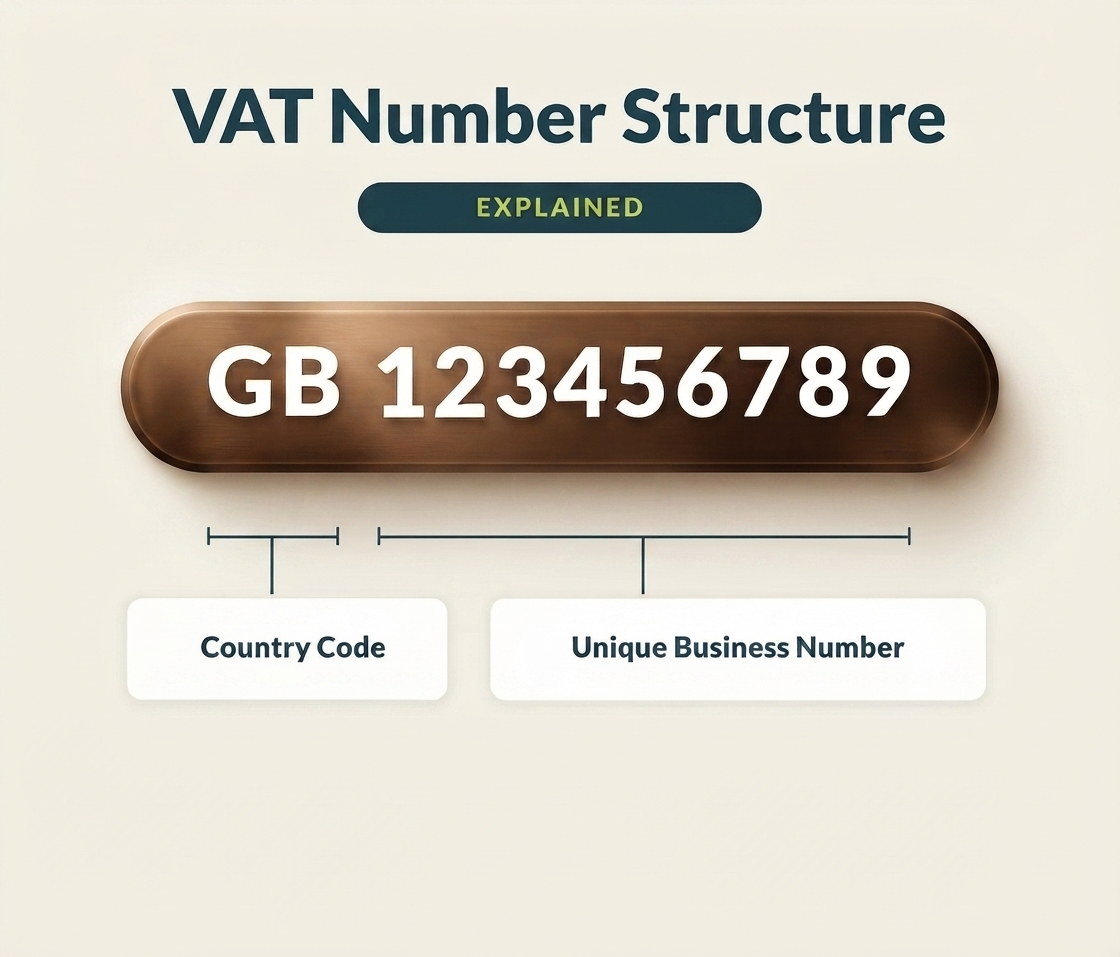

- **Country code**, `GB` for Great Britain (or `XI` specifically for Northern Ireland businesses trading with the EU under the post-Brexit protocol).
- **Unique business number**, 9 digits, where the **last 2 digits are a checksum** of the first 7, computed with a modulus-97 algorithm.

That checksum matters a lot for this project: it means most random 9-digit strings are *not* valid VAT numbers (roughly 1 in 97 is), so it gives us a cheap, offline way to reject obvious noise before spending any real verification effort. It does **not** mean a checksum-valid number is real or belongs to the right company, only that it's *structurally possible*. That distinction, plausible vs. verified, turns out to be the single most important idea in this whole project, and it comes back constantly below.


## 2. Where could a VAT number actually be found?, first pass at sources

After some initial research, four broad discovery routes emerged. None of them is free of trade-offs, and the trade-offs are the interesting part.

| # | Source | Pros | Cons |
|---|---|---|---|
| 1 | **The company's own website** (terms page, footer, invoices template) | Easiest method when it works, the number is right there in plain text, in the company's own words, so provenance is clean | Only a small minority of companies publish it. There is **no general legal requirement** to show a VAT number on a website, only on VAT invoices themselves. The only exception is the Electronic Commerce (EC Directive) Regulations 2002, which requires disclosure for businesses that operate an "information society service" (in practice: sites that let you transact online). A brochure site with no checkout has no such duty. |
| 2 | **Invoices or receipts from a transaction with the company** | Legally required to be present and accurate, if you've ever bought something from the company, this is the single most reliable source, better than a website scrape | Only exists if you (or the customer) has actually transacted with the supplier. Not scalable as a *discovery* method, you can't invoice a company you've never bought from just to learn its VAT number. Useful for verifying a number you already suspect, not for cold discovery across 40,000 unknown suppliers. |
| 3 | **Direct contact with the company** (e.g. an email asking for their VAT number) | Ground-truth accurate if they reply, and legitimate, VAT-registered businesses are used to being asked this in B2B contexts | Doesn't scale to tens of thousands of suppliers at all; slow, depends on someone at the company actually answering, and a "we'll get back to you" response rate that's realistically nowhere near 100%. This is a fallback for a handful of high-value gaps, not a pipeline. |
| 4 | **Third-party VAT lookup directories** (e.g. `vat-lookup.co.uk`, `vat-search.co.uk`) | Already did some of the discovery work for you, searchable by company name, no crawling required on your end | Coverage is partial and the provenance is unclear (where did *they* get the number from? Usually the same public sources listed above, aggregated). They can also simply be down, tested live below. Not something you'd want to depend on for a paid product without knowing their sourcing. |

Source #1 and #4 are the two that are actually automatable at scale, so the rest of this notebook focuses there, but #2 and #3 stay relevant as *verification* fallbacks for specific high-value gaps, even if they can't be the backbone of discovery.


## 3. Companies House Free Company Data Product, the anchor dataset

`download.companieshouse.gov.uk` publishes a free monthly CSV snapshot of ~5 million companies (company number, name, address, SIC codes, incorporation date, status, filing dates). I confirmed the field list against the official schema PDF.

It contains **no website field and no VAT field**. This is the anchor dataset, the "truth" you're trying to enrich, but it contributes nothing to discovery directly. What it *does* give you is the two things you need before you can even start looking:

1. **The universe of company names and numbers** to match candidate VAT numbers back against.
2. **SIC codes**, which let you prioritise which companies are actually worth crawling first, a dormant holding company is never going to have a discoverable VAT number anywhere, while an e-commerce-coded company is much more likely to publish one under the Ecommerce Regulations noted above.

So Companies House is the starting point of the pipeline (the list of who to look for), not a source of the answer itself.


## 3. Companies House Free Company Data Product, the anchor dataset

`download.companieshouse.gov.uk` publishes a free monthly CSV snapshot of ~5 million companies (company number, name, address, SIC codes, incorporation date, status, filing dates). I confirmed the field list against the official schema PDF.

It contains **no website field and no VAT field**. This is the anchor dataset, the "truth" you're trying to enrich, but it contributes nothing to discovery directly. What it *does* give you is the two things you need before you can even start looking:

1. **The universe of company names and numbers** to match candidate VAT numbers back against.
2. **SIC codes**, which let you prioritise which companies are actually worth crawling first, a dormant holding company is never going to have a discoverable VAT number anywhere, while an e-commerce-coded company is much more likely to publish one under the Ecommerce Regulations noted above.

So Companies House is the starting point of the pipeline (the list of who to look for), not a source of the answer itself.

## 4. Difficulties encountered

### 4.1 A third-party VAT lookup site, but with real coverage limits

Beyond `vat-lookup.co.uk`, I found another public checker where you type in a company name and it returns a VAT number if it has one on file. It looked promising at first, but two problems showed up quickly:

- **Coverage is partial.** It clearly isn't built from a complete registry, only from whatever numbers it managed to scrape or was fed at some point. A meaningful share of real, active, VAT-registered companies simply return nothing, not because they lack a VAT number, but because the site never indexed it.
- **Rate limiting is aggressive.** I tried to reverse-engineer whether there's a pattern to *which* Companies House entries actually return a VAT number on this checker (e.g. by SIC code, incorporation age, region) by running it against a batch of names pulled from the Companies House free data file. After roughly 50 requests, the site blocked my IP outright. That kills any attempt to profile the site's coverage systematically, and it rules the site out as a serious *bulk* discovery method, not just a slow one, but a genuinely blocked one.

This is a useful negative result on its own: it confirms that free third-party checkers are built for occasional, one-off human lookups, not for feeding a pipeline. Any real use of a source like this would need either a paid/authorised bulk tier, or a much slower, deliberately throttled crawl that respects the site's limits, which changes the economics of using it at all.

### 4.2 The EORI number as a deterministic shortcut

This is the strongest lead from the "adjacent identifiers" idea in the original brief, and worth spelling out precisely, because it's not a probabilistic match, it's a direct derivation.

**How it works:** since Brexit, a UK-based, VAT-registered trader's EORI number (Economic Operator Registration and Identification, needed to move goods across the UK border) is built directly from their VAT number:

```
EORI = "GB" + <9-digit VAT number> + "000"
```

Example: a company with VAT `GB123456789` will have EORI `GB123456789000` if it has one at all. This means the relationship is **1:1 and reversible**: strip the `GB` prefix and the trailing `000`, and what's left *is* the VAT number, no matching step, no fuzzy comparison, no ambiguity about whether it's the right company.

**Why this matters for the pipeline:** every other discovery route in this project (scraping a footer, parsing a G-Cloud PDF) produces a *candidate* that still needs checksum filtering and, ideally, verification. An EORI-derived number comes with the VAT number built into its own structure, so if you can find a company's EORI through any channel, you've found its VAT number by construction, not by inference.

**Where an EORI might be findable:**
- HMRC's own EORI checker (public-facing, similar shape to the VAT checker discussed earlier).
- UK Trade Info, which publishes customs and trade statistics and, depending on the dataset, may expose EORI-linked records.
- Commercial shipping/import databases (e.g. ImportYeti-style services) that index bills of lading and customs filings, which often carry the shipper's EORI.

**The catch:** this only covers companies that import or export goods and therefore needed an EORI in the first place. A domestic-only service company (an accountant, a local supplier) will never have one, so this is a high-precision, low-recall source, it's excellent when it hits, but it only hits for a specific subset of the target population (traders, not all VAT-registered companies).

### 4.3 Bulk discovery via HMRC APIs vs. Peppol

Two candidate routes for scaling identifier discovery beyond individual lookups:

- **HMRC's own APIs** (EORI checker, VAT checker) are the natural first choice, since they're the authoritative source, but as covered earlier, the open bulk-access version was retired, so scale here depends on getting an approved v2 credential.
- **Peppol** (the pan-European e-invoicing/e-delivery network, which UK public bodies and many suppliers connect to) is a real alternative to consider, since Peppol participant directories expose registered business identifiers, VAT numbers among them, for companies that are Peppol-connected. I looked into it as a bulk option and ruled it out for this scale of problem: Peppol's lookup service is throttled to roughly **2 queries per second**. Against a target list in the tens of thousands (let alone the ~2.9M "live and trading" universe from Companies House), that rate limit alone stretches a full pass into days, before accounting for the fact that only Peppol-connected companies would ever show up in it at all. It's a plausible secondary source for a small, already-known set of suppliers, not a primary discovery channel at scale.
